In [1]:
import os
import json
import glob
from tqdm import tqdm
import rasterio
import numpy as np
from collections import Counter, defaultdict
from sklearn.model_selection import train_test_split
import random
import matplotlib.pyplot as plt

In [2]:
BASE_PATH = r"C:\Users\Agando\Documents\Bachelorarbeit\DFC_Public_Dataset_ORIGINAL"

def get_majority_class(mask_path):
    with rasterio.open(mask_path) as src:
        mask = src.read(1)
    flat = mask.flatten()
    counts = Counter(flat)

    for cls, _ in counts.most_common():
        if cls in DFC20_LABEL_MAP:
            return DFC20_LABEL_MAP[cls]

    # If no valid class found, return None (can be filtered out)
    return None

# Mapping DFC20 class IDs to 0-7 continuous range
DFC20_LABEL_MAP = {
    1: 0,   # Forest
    2: 1,   # Shrubland
    4: 2,   # Grassland
    5: 3,   # Wetlands
    6: 4,   # Croplands
    7: 5,   # Urban/Built-up
    9: 6,   # Barren
    10: 7   # Water
}

In [ ]:
metadata = []

roi_folders = [f for f in os.listdir(BASE_PATH) if f.startswith("ROIs")]

for roi_folder in roi_folders:
    roi_path = os.path.join(BASE_PATH, roi_folder)
    dfc_folders = glob.glob(os.path.join(roi_path, "dfc_*"))

    for dfc_folder in dfc_folders:
        scene = os.path.basename(dfc_folder).replace("dfc_", "")
        dfc_files = glob.glob(os.path.join(dfc_folder, "*.tif"))

        for dfc_path in tqdm(dfc_files, desc=f"{scene} in {roi_folder}"):
            filename = os.path.basename(dfc_path)
            patch_id = filename

            s1_path = os.path.join(roi_path, f"s1_{scene}", filename.replace("dfc", "s1"))
            s2_path = os.path.join(roi_path, f"s2_{scene}", filename.replace("dfc", "s2"))

            if not (os.path.exists(s1_path) and os.path.exists(s2_path)):
                print(f"[!] Missing s1/s2 for {patch_id}")
                continue

            try:
                majority_class = get_majority_class(dfc_path)
                if majority_class is None:
                    print(f"[!] No valid class in {patch_id}")
                    continue
            except Exception as e:
                print(f"[!] Error reading {dfc_path}: {e}")
                continue

            metadata.append({
                "id": patch_id,
                "scene": scene,
                "roi_folder": roi_folder,
                "path_dfc": dfc_path,
                "path_s1": s1_path,
                "path_s2": s2_path,
                "majority_class": majority_class
            })

# Save to file
with open("patch_metadata.json", "w") as f:
    json.dump(metadata, f, indent=2)

print(f"\nSaved metadata for {len(metadata)} patches.")

MexicoCity in ROIs0000_winter: 100%|██████████| 484/484 [00:04<00:00, 106.69it/s]


✅ Saved metadata for 6114 patches.


In [4]:
random.seed(42)

# Load metadata
with open("patch_metadata.json") as f:
    metadata = json.load(f)

# Group patches by scene
scene_groups = defaultdict(list)
for item in metadata:
    scene = item["scene"]
    scene_groups[scene].append(item)

# Initialize splits
train_ids, val_ids, test_ids = [], [], []
"""
# Split each scene into 80% train, 10% val, 10% test
for scene, patches in scene_groups.items():
    random.shuffle(patches)
    n = len(patches)
    n_train = int(0.8 * n)
    n_val = int(0.1 * n)

    train_ids += [p["id"] for p in patches[:n_train]]
    val_ids   += [p["id"] for p in patches[n_train:n_train + n_val]]
    test_ids  += [p["id"] for p in patches[n_train + n_val:]]
"""
scenes = list(scene_groups.keys())  # All scene names
random.shuffle(scenes)              # Shuffle scene list

n_total = len(scenes)
n_train = int(0.8 * n_total)
n_val = int(0.1 * n_total)
n_test = n_total - n_train - n_val  # ensure full coverage

# Ensure at least 1 scene in each split
if n_val == 0:
    n_val = 1
    n_train = max(n_train - 1, 1)  # keep train >= 1

if n_test == 0:
    n_test = 1
    n_train = max(n_train - 1, 1)

# Assign scene slices
train_scenes = scenes[:n_train]
val_scenes = scenes[n_train:n_train + n_val]
test_scenes = scenes[n_train + n_val:]

# Now collect all patches (by ID) from scenes assigned to each split
train_ids = [p["id"] for s in train_scenes for p in scene_groups[s]]
val_ids = [p["id"] for s in val_scenes for p in scene_groups[s]]
test_ids = [p["id"] for s in test_scenes for p in scene_groups[s]]

# Optional sanity check
print(f"Split scenes: train={len(train_scenes)}, val={len(val_scenes)}, test={len(test_scenes)}")
print(f"Split patches: train={len(train_ids)}, val={len(val_ids)}, test={len(test_ids)}")

# Save splits
with open("train_ids2.json", "w") as f:
    json.dump(train_ids, f)
with open("val_ids2.json", "w") as f:
    json.dump(val_ids, f)
with open("test_ids2.json", "w") as f:
    json.dump(test_ids, f)

print(f"Train: {len(train_ids)} | Val: {len(val_ids)} | Test: {len(test_ids)}")

Split scenes: train=4, val=1, test=2
Split patches: train=4270, val=484, test=1360
Train: 4270 | Val: 484 | Test: 1360



📊 Percentage Distribution (by Majority Class):
Class         All    Train      Val     Test
0           26.17    26.28    24.96    26.46
1            5.25     5.24     4.76     5.84
2            6.15     6.07     6.40     6.49
3            3.45     3.48     2.96     3.73
4           22.41    22.52    22.00    21.92
5            9.65     9.78     9.20     9.09
6            1.62     1.47     2.46     1.95
7           25.30    25.16    27.26    24.51


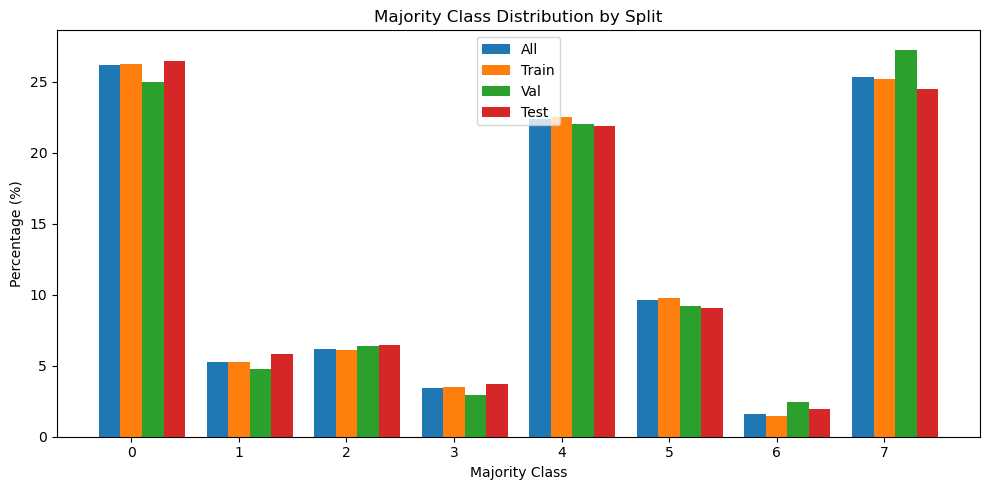

In [28]:
####### MAJORITY CLASS DISTRIBUTION #######

# Load metadata
with open("patch_metadata.json") as f:
    metadata = json.load(f)

# Load split IDs
with open("train_ids.json") as f:
    train_ids = set(json.load(f))
with open("val_ids.json") as f:
    val_ids = set(json.load(f))
with open("test_ids.json") as f:
    test_ids = set(json.load(f))

# Build lookup: patch_id → majority_class
id_to_class = {item["id"]: item["majority_class"] for item in metadata}

# Collect majority classes per split
train_classes = [id_to_class[i] for i in train_ids if i in id_to_class]
val_classes = [id_to_class[i] for i in val_ids if i in id_to_class]
test_classes = [id_to_class[i] for i in test_ids if i in id_to_class]
all_classes = list(id_to_class.values())

# Count occurrences
counts = {
    "All": Counter(all_classes),
    "Train": Counter(train_classes),
    "Val": Counter(val_classes),
    "Test": Counter(test_classes),
}

# Get sorted unique class labels
labels = sorted(set(all_classes))

# Convert counts to percentages
percentages = {}
for split, counter in counts.items():
    total = sum(counter.values())
    percentages[split] = {label: (counter.get(label, 0) / total) * 100 for label in labels}

# Print percentage distribution
print("\n📊 Percentage Distribution (by Majority Class):")
print(f"{'Class':<8} {'All':>8} {'Train':>8} {'Val':>8} {'Test':>8}")
for label in labels:
    a = percentages["All"].get(label, 0)
    t = percentages["Train"].get(label, 0)
    v = percentages["Val"].get(label, 0)
    s = percentages["Test"].get(label, 0)
    print(f"{label:<8} {a:8.2f} {t:8.2f} {v:8.2f} {s:8.2f}")

# Optional: plot as bar chart
fig, ax = plt.subplots(figsize=(10, 5))
width = 0.2
x = range(len(labels))
for i, split in enumerate(["All", "Train", "Val", "Test"]):
    heights = [percentages[split].get(label, 0) for label in labels]
    ax.bar([xi + i * width for xi in x], heights, width=width, label=split)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(labels)
ax.set_xlabel("Majority Class")
ax.set_ylabel("Percentage (%)")
ax.set_title("Majority Class Distribution by Split")
ax.legend()
plt.tight_layout()
plt.show()

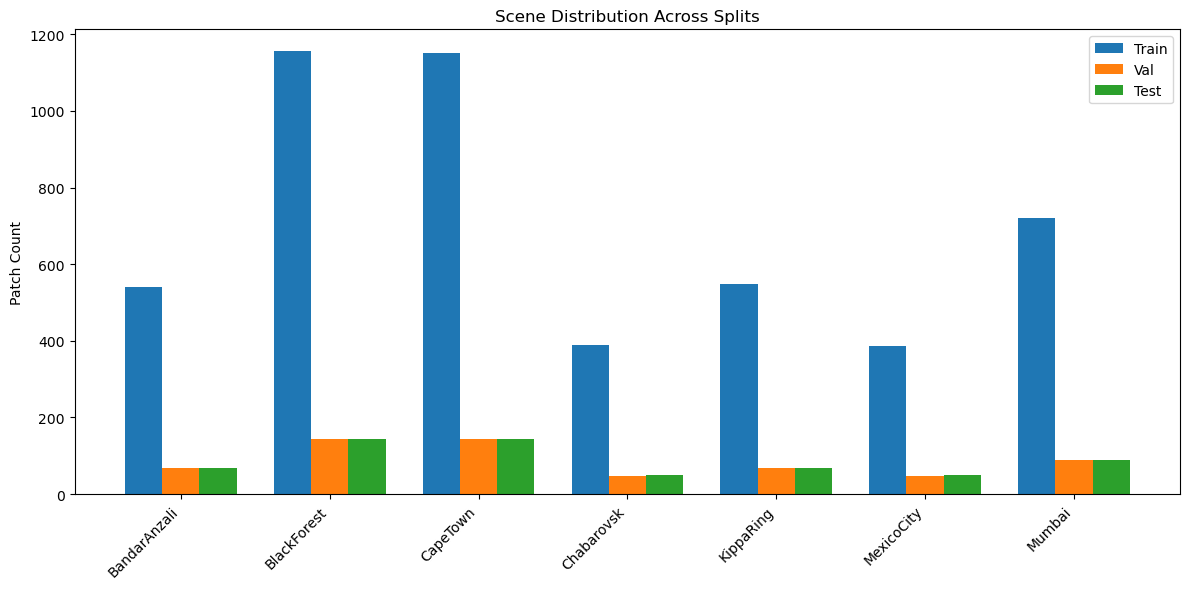


📊 Scene Distribution Table (patch count per scene):
Scene                 Train    Val   Test
BandarAnzali            540     67     69
BlackForest            1155    144    145
CapeTown               1152    144    144
Chabarovsk              388     48     50
KippaRing               547     68     69
MexicoCity              387     48     49
Mumbai                  720     90     90


In [ ]:
####### SCENE DISTRIBUTION #######

# Load metadata
with open("patch_metadata.json") as f:
    metadata = json.load(f)

# Load split IDs
with open("train_ids.json") as f:
    train_ids = set(json.load(f))
with open("val_ids.json") as f:
    val_ids = set(json.load(f))
with open("test_ids.json") as f:
    test_ids = set(json.load(f))

# Map ID to scene name
id_to_scene = {item["id"]: item["scene"] for item in metadata}

# Group scene names by split
scene_counts = {
    "Train": Counter(id_to_scene[i] for i in train_ids if i in id_to_scene),
    "Val": Counter(id_to_scene[i] for i in val_ids if i in id_to_scene),
    "Test": Counter(id_to_scene[i] for i in test_ids if i in id_to_scene),
}

# Get list of all scenes
all_scenes = sorted(set(id_to_scene.values()))
x = range(len(all_scenes))
width = 0.25

# Plot
fig, ax = plt.subplots(figsize=(12, 6))

for i, split in enumerate(["Train", "Val", "Test"]):
    counts = [scene_counts[split].get(scene, 0) for scene in all_scenes]
    ax.bar([xi + i * width for xi in x], counts, width=width, label=split)

ax.set_xticks([xi + width for xi in x])
ax.set_xticklabels(all_scenes, rotation=45, ha="right")
ax.set_ylabel("Patch Count")
ax.set_title("Scene Distribution Across Splits")
ax.legend()
plt.tight_layout()
plt.show()

# Print counts as a table
print("\n📊 Scene Distribution Table (patch count per scene):")
print(f"{'Scene':<20} {'Train':>6} {'Val':>6} {'Test':>6}")
for scene in all_scenes:
    t = scene_counts["Train"].get(scene, 0)
    v = scene_counts["Val"].get(scene, 0)
    s = scene_counts["Test"].get(scene, 0)
    print(f"{scene:<20} {t:6} {v:6} {s:6}")